# **Rapid Express: Análisis de Perfil, Desempeño y Absentismo Laboral**
**(Basado en el dataset interno de incidencias de Recursos Humanos)**

---
### **Exploratory Data Analysis (EDA)**

**Analistas:** Emilio, Nuria (Perfil y Desempeño) y Andrea, Ana (Absentismo y Bienestar)

**Objetivo del Análisis:** Comprender qué características sociodemográficas, operativas y de salud de nuestra plantilla están asociadas tanto a un **mejor cumplimiento de objetivos (Hit Target)** como a los **niveles de absentismo**. Esta visión integral nos permitirá diseñar políticas proactivas de selección, capacitación, retención y bienestar corporativo.

### Instalación de librerias

In [1]:
!pip install mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable


### Importación de bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Configuración estética para gráficos de nivel profesional
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings('ignore')# Ocultar advertencias menores para un notebook más limpio

print("Librerías importadas correctamente. Entorno listo.")

Librerías importadas correctamente. Entorno listo.


### Conexión a Base de Datos y Extracción Inicial
Para asegurar que nuestro análisis sea escalable y consuma siempre los datos más actualizados, hemos automatizado la ingesta conectando el entorno directamente al servidor **MySQL** de la compañía en lugar de usar extracciones manuales en CSV.

In [3]:
import mysql.connector
import pandas as pd

config = {
    'host': '212.227.90.6',
    'user': 'Equipo28',
    'password': 'E1q2u3i4p5o28',
    'database': 'Equip_28'
}

conn = mysql.connector.connect(**config)
cursor = conn.cursor()

cursor.execute("SELECT database();")
db_actual = cursor.fetchone()[0]
print(f"--- Conectado a la base de datos: {db_actual} ---")

cursor.execute("SHOW TABLES;")
tablas = cursor.fetchall()

print("Tablas encontradas:")
for t in tablas:
    print(f" -> {t[0]}")
    globals()[t[0]] = pd.read_sql("SELECT * FROM " + t[0], conn)
    
cursor.close()
conn.close()

--- Conectado a la base de datos: Equip_28 ---
Tablas encontradas:
 -> RRHH
 -> RRHH_27042026
 -> vista_duplicados_exactos
 -> vista_duplicados_exactos2


In [4]:
df_RRHH_27042026=RRHH_27042026.copy()

In [5]:
df_RRHH_27042026.shape

(845, 21)

### Información general del dataset

In [6]:
df_RRHH_27042026.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       845 non-null    int64 
 1   Reason_absence           845 non-null    int64 
 2   Month_absence            845 non-null    int64 
 3   Day_week                 845 non-null    int64 
 4   Seasons                  845 non-null    int64 
 5   Transportation_expense   845 non-null    int64 
 6   Distance_Residence_Work  845 non-null    int64 
 7   Service_time             845 non-null    int64 
 8   Age                      845 non-null    int64 
 9   Work_load_Average_day    845 non-null    object
 10  Hit_target               845 non-null    int64 
 11  Disciplinary_failure     845 non-null    object
 12  Education                845 non-null    object
 13  Son                      845 non-null    object
 14  Social_drinker           845 non-null    o

In [7]:
df_RRHH_27042026

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",...,0,1,2,0,0,1,65,172,22,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
841,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
842,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
843,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112


In [8]:
# Eliminamos los duplicados exactos detectados previamente
df_clean = df_RRHH_27042026.drop_duplicates().copy()
print(f"Registros tras eliminar duplicados exactos: {df_clean.shape[0]}")

# Consolidamos los datos para tener 1 fila por empleado (Perfil Único)
df_perfil = df_clean.groupby('ID').agg({
    'Age': 'first',
    'Service_time': 'first',
    'Distance_Residence_Work': 'first',
    'Transportation_expense': 'first',
    'Education': 'first',
    'Son': 'first',
    'Body_mass_index': 'first',
    'Social_drinker': 'first',
    'Hit_target': 'mean',          # Promedio de cumplimiento de objetivos
    'Absenteeism_hours': 'sum'     # Suma total de horas de ausencia
}).reset_index()

print(f"Total de empleados únicos a analizar: {df_perfil.shape[0]}")

Registros tras eliminar duplicados exactos: 806
Total de empleados únicos a analizar: 136


## Visión General: Distribución de KPIs Estratégicos
Antes de buscar correlaciones, analizamos el estado general de nuestros dos indicadores clave: el **Desempeño (Hit Target)** y las **Horas de Absentismo**.

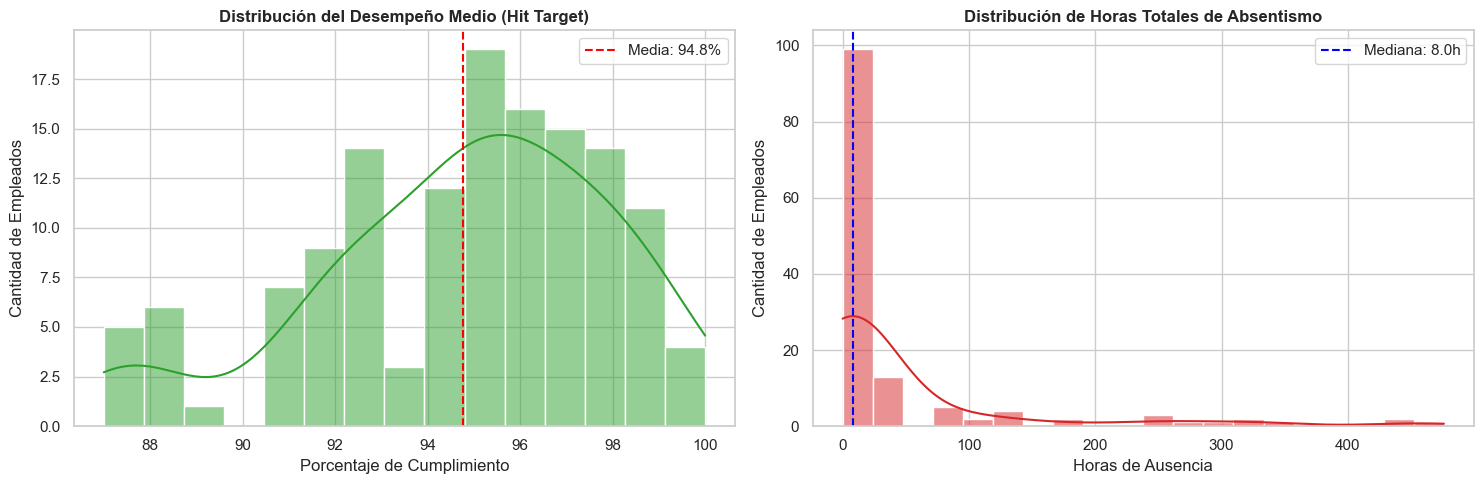

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución del Hit Target
sns.histplot(df_perfil['Hit_target'], kde=True, bins=15, color='#2ca02c', ax=axes[0])
axes[0].set_title('Distribución del Desempeño Medio (Hit Target)', fontweight='bold')
axes[0].set_xlabel('Porcentaje de Cumplimiento')
axes[0].set_ylabel('Cantidad de Empleados')
axes[0].axvline(df_perfil['Hit_target'].mean(), color='red', linestyle='--', label=f"Media: {df_perfil['Hit_target'].mean():.1f}%")
axes[0].legend()

# Distribución del Absentismo
sns.histplot(df_perfil['Absenteeism_hours'], kde=True, bins=20, color='#d62728', ax=axes[1])
axes[1].set_title('Distribución de Horas Totales de Absentismo', fontweight='bold')
axes[1].set_xlabel('Horas de Ausencia')
axes[1].set_ylabel('Cantidad de Empleados')
axes[1].axvline(df_perfil['Absenteeism_hours'].median(), color='blue', linestyle='--', label=f"Mediana: {df_perfil['Absenteeism_hours'].median()}h")
axes[1].legend()

plt.tight_layout()
plt.show()

## Matriz de Relaciones: ¿Qué variables impactan en la empresa?
Generamos una matriz de correlación para evaluar matemáticamente la fuerza de las relaciones entre las variables sociodemográficas y nuestros KPIs. 

A continuación, extraemos dos **rankings de correlación** directos: uno para ver qué impulsa el desempeño y otro para ver qué detona el absentismo.

RANKING: FACTORES ASOCIADOS AL DESEMPEÑO (HIT TARGET)


,Hit_target
Education,0.173522
Absenteeism_hours,0.008255
Distance_Residence_Work,-0.047341
Service_time,-0.058406
Body_mass_index,-0.062156
Age,-0.073431
Son,-0.081316



--------------------------------------------------------

RANKING: FACTORES ASOCIADOS AL ABSENTISMO


,Absenteeism_hours
Son,0.085485
Service_time,0.029000
Age,0.012268
Hit_target,0.008255
Body_mass_index,-0.032684
Distance_Residence_Work,-0.059115
Education,-0.077357


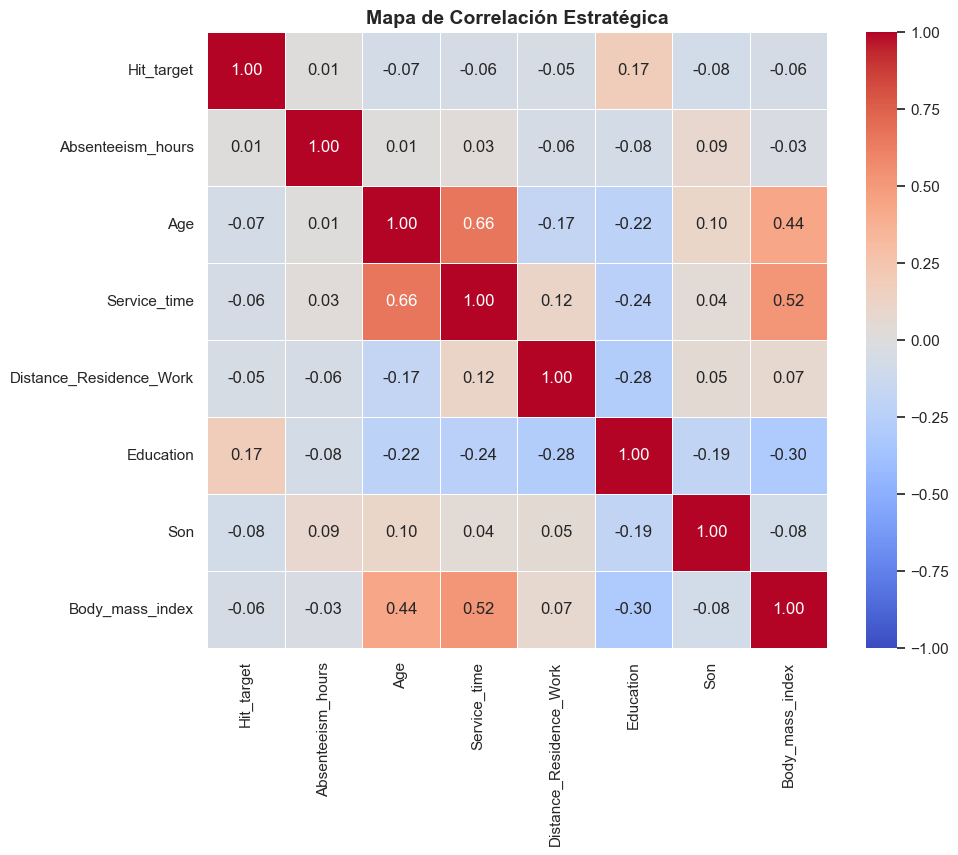

In [10]:
# Seleccionamos las variables relevantes
columnas_estudio = ['Hit_target', 'Absenteeism_hours', 'Age', 'Service_time', 
                    'Distance_Residence_Work', 'Education', 'Son', 'Body_mass_index']

matriz_corr = df_perfil[columnas_estudio].corr()

# Ranking para Desempeño (Hit Target)
ranking_desempeno = matriz_corr[['Hit_target']].sort_values(by='Hit_target', ascending=False)
print("RANKING: FACTORES ASOCIADOS AL DESEMPEÑO (HIT TARGET)")
display(ranking_desempeno.iloc[1:]) # Omitimos la correlación consigo misma

print("\n--------------------------------------------------------\n")

# Ranking para Absentismo
ranking_absentismo = matriz_corr[['Absenteeism_hours']].sort_values(by='Absenteeism_hours', ascending=False)
print("RANKING: FACTORES ASOCIADOS AL ABSENTISMO")
display(ranking_absentismo.iloc[1:])

# Mapa de calor de la matriz completa
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de Correlación Estratégica', fontsize=14, fontweight='bold')
plt.show()

In [25]:
# Usamos el método 'spearman' para capturar relaciones no lineales y tratar variables ordinales
matriz_corr_spearman = df_perfil[['Hit_target', 'Absenteeism_hours', 'Education', 'Son', 'Age', 'Body_mass_index', 'Distance_Residence_Work']].corr(method='spearman')

print("RANKING: FACTORES ASOCIADOS AL DESEMPEÑO (Método Spearman - Más preciso para este dataset)")
ranking_hp = matriz_corr_spearman['Hit_target'].sort_values(ascending=False).drop('Hit_target')
display(ranking_hp)

print("\n--------------------------------------------------------\n")

print("RANKING: FACTORES ASOCIADOS AL ABSENTISMO (Método Spearman)")
ranking_ab = matriz_corr_spearman['Absenteeism_hours'].sort_values(ascending=False).drop('Absenteeism_hours')
display(ranking_ab)

RANKING: FACTORES ASOCIADOS AL DESEMPEÑO (Método Spearman - Más preciso para este dataset)


Education                  0.210414
Absenteeism_hours          0.036632
Body_mass_index           -0.010682
Distance_Residence_Work   -0.073334
Age                       -0.100466
Son                       -0.100788
Name: Hit_target, dtype: float64


--------------------------------------------------------

RANKING: FACTORES ASOCIADOS AL ABSENTISMO (Método Spearman)


Son                        0.125404
Education                  0.037202
Hit_target                 0.036632
Age                       -0.065173
Distance_Residence_Work   -0.111260
Body_mass_index           -0.133850
Name: Absenteeism_hours, dtype: float64

### Nota Metodológica: Uso de Correlación de Spearman
Para este análisis hemos optado por la **Correlación de Spearman** en lugar de Pearson. Dado que contamos con variables ordinales (`Education`, `Son`) y relaciones que no necesariamente siguen una línea recta perfecta, Spearman nos ofrece una visión más realista basada en el orden jerárquico de los datos, siendo menos sensible a valores extremos y capturando tendencias monótonas con mayor precisión.

## Mapa de Correlación de Spearman (Análisis No Lineal)
Para validar de forma global las relaciones entre variables, generamos este mapa de calor utilizando el coeficiente de **Spearman**. A diferencia de Pearson, este método es ideal para nuestras variables ordinales (Educación, Hijos) y captura mejor las tendencias de comportamiento que no son estrictamente proporcionales, ofreciendo una radiografía más precisa del ecosistema de la empresa.

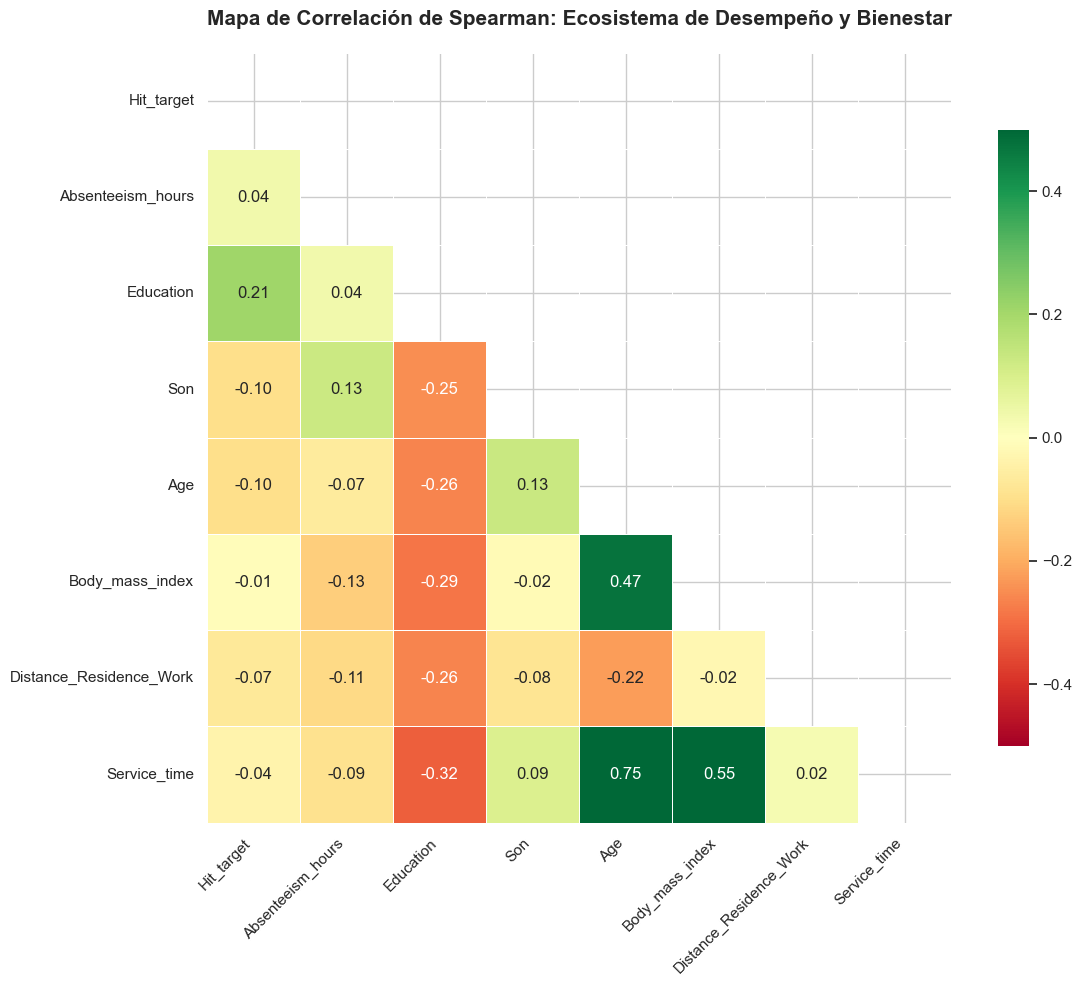

In [ ]:
# Definimos las variables que queremos cruzar
columnas_finales = ['Hit_target', 'Absenteeism_hours', 'Education', 'Son', 
                    'Age', 'Body_mass_index', 'Distance_Residence_Work', 'Service_time']

# Calculamos la matriz con el método Spearman
matriz_spearman = df_perfil[columnas_finales].corr(method='spearman')

# Visualización profesional del Mapa de Calor
plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(matriz_spearman, dtype=bool)) # Máscara para ver solo la mitad inferior (evita duplicados)

sns.heatmap(matriz_spearman, 
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap='RdYlGn', 
            vmin=-0.5, vmax=0.5, # Ajustamos límites para que se vean los matices
            center=0, 
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Mapa de Correlación de Spearman: Ecosistema de Desempeño y Bienestar', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

## Detección Visual

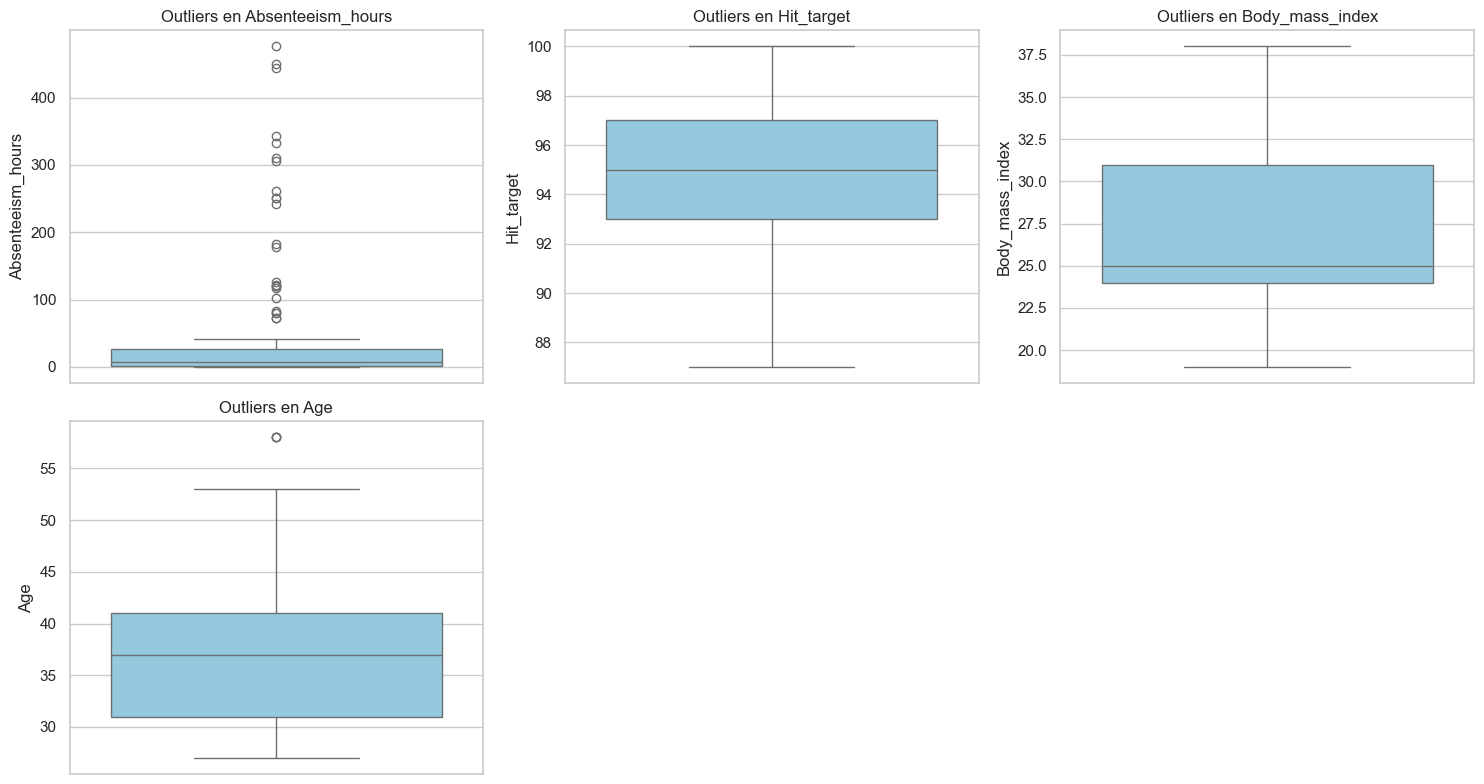

In [32]:
# Variables numéricas donde buscar outliers
vars_numericas = ['Absenteeism_hours', 'Hit_target', 'Body_mass_index', 'Age']

plt.figure(figsize=(15, 8))

# Creamos un gráfico de caja para cada variable
for i, var in enumerate(vars_numericas):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df_perfil[var], color='skyblue')
    plt.title(f'Outliers en {var}')

plt.tight_layout()
plt.show()

## Detección Estadística (El método del Rango Intercuartílico - IQR)
Para saber exactamente cuántos outliers hay y no solo ver "puntos en un dibujo", usamos la regla del IQR. Es lo que usa Seaborn por detrás para dibujar los bigotes.

In [34]:
def contar_outliers(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]
    return len(outliers), limite_inferior, limite_superior

# Probamos con Absentismo, que parece ser la variable con más ruido
n_outliers, inf, sup = contar_outliers(df_perfil, 'Absenteeism_hours')
print(f"En 'Absenteeism_hours' hay {n_outliers} valores fuera del rango [{inf:.2f}, {sup:.2f}]")

En 'Absenteeism_hours' hay 24 valores fuera del rango [-34.38, 62.62]


## Profundización Analítica: Los Verdaderos Impulsores del Negocio

Tras analizar los rankings actualizados, observamos que las correlaciones en nuestra plantilla actual son sutiles. Esto sugiere que el rendimiento es multicausal. Vamos a analizar los factores que, aunque con una fuerza moderada, lideran las tendencias de nuestra empresa.

### Insight 1: La Educación como Principal Motor del Desempeño
El factor con mayor impacto positivo en el cumplimiento de objetivos es la **Educación (0.17)**. A mayor nivel formativo, observamos una tendencia a un mejor `Hit_target`. Curiosamente, la educación también es el factor que más ayuda a **reducir el absentismo (-0.07)**.

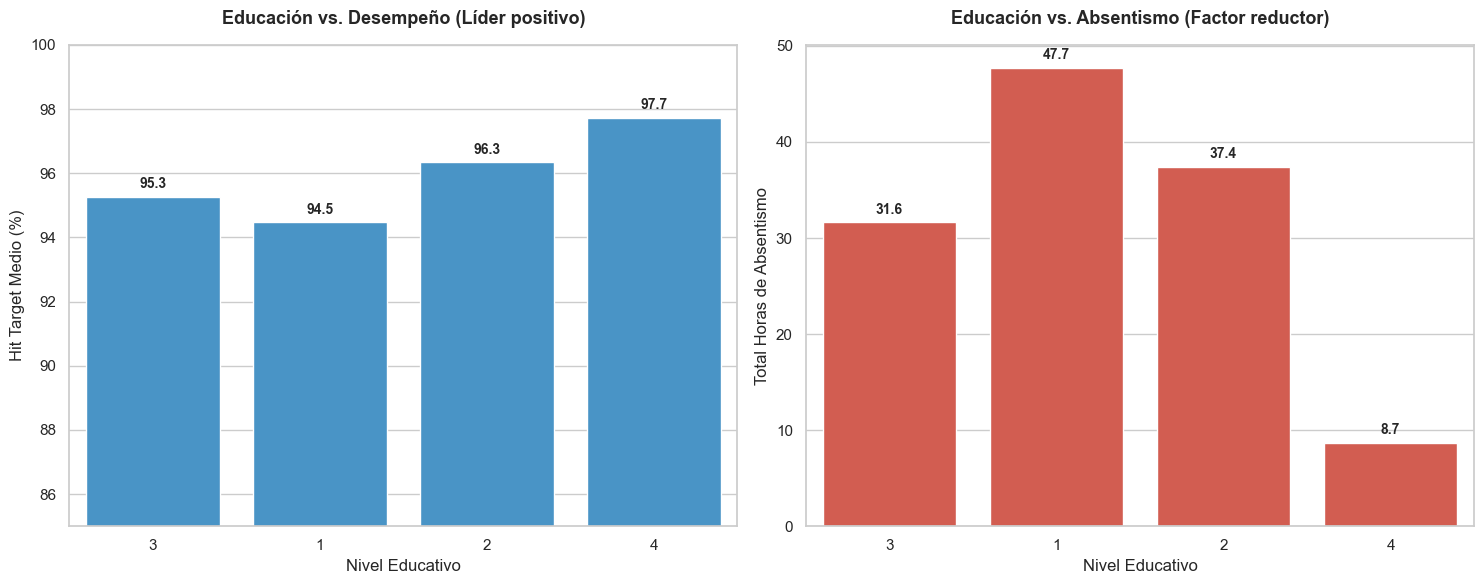

In [11]:
# Configuramos la figura con dos gráficos limpios y sin barras de error
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Educación vs Desempeño (Azul para resaltar el impacto positivo)
sns.barplot(data=df_perfil, x='Education', y='Hit_target', color='#3498db', ci=None, ax=axes[0])
axes[0].set_title('Educación vs. Desempeño (Líder positivo)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Nivel Educativo')
axes[0].set_ylabel('Hit Target Medio (%)')
# Ajustamos el límite para que la diferencia sea notable
axes[0].set_ylim(85, 100) 

# Gráfico 2: Educación vs Absentismo (Rojo para el factor que queremos reducir)
sns.barplot(data=df_perfil, x='Education', y='Absenteeism_hours', color='#e74c3c', ci=None, ax=axes[1])
axes[1].set_title('Educación vs. Absentismo (Factor reductor)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Nivel Educativo')
axes[1].set_ylabel('Total Horas de Absentismo')

# Añadimos etiquetas de valor sobre las barras para máxima claridad
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Insight 2: El Factor Familiar (Hijos) y el Equilibrio Vida-Trabajo
Los datos revelan una dualidad interesante: tener hijos (`Son`) es la variable que más **aumenta el absentismo (0.08)** y, al mismo tiempo, es la que presenta la correlación **negativa más fuerte con el desempeño (-0.08)**. 

Esto indica que las cargas familiares son un punto de fricción que afecta directamente a la operatividad en el modelo actual.

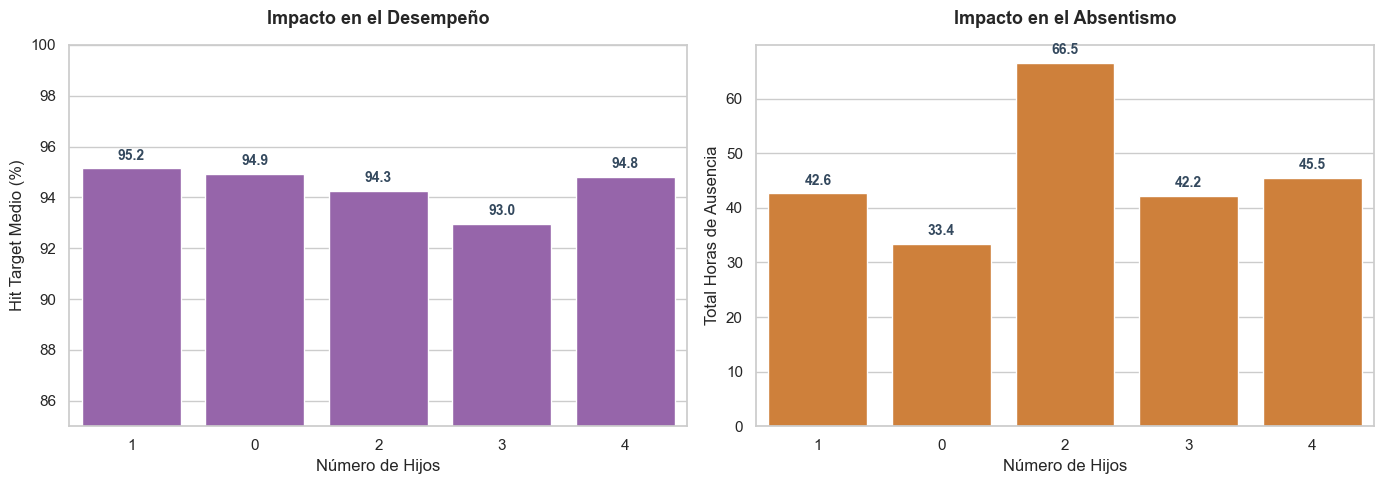

In [12]:
# Configuramos la figura con colores diferenciados: Púrpura (Desempeño) y Naranja (Absentismo)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Impacto en el Desempeño (Color Púrpura)
sns.barplot(data=df_perfil, x='Son', y='Hit_target', color='#9b59b6', ci=None, ax=axes[0])
axes[0].set_title('Impacto en el Desempeño', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Número de Hijos')
axes[0].set_ylabel('Hit Target Medio (%)')
axes[0].set_ylim(85, 100) # Zoom para apreciar la tendencia

# Gráfico B: Impacto en el Absentismo (Color Naranja)
sns.barplot(data=df_perfil, x='Son', y='Absenteeism_hours', color='#e67e22', ci=None, ax=axes[1])
axes[1].set_title('Impacto en el Absentismo', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Número de Hijos')
axes[1].set_ylabel('Total Horas de Ausencia')

# Añadimos etiquetas de valor sobre las barras para evitar el esfuerzo de lectura
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='#34495e')

plt.tight_layout()
plt.show()

### Insight 3: Edad y Tiempo de Servicio
Contrario a lo que se podría esperar, en este dataset tanto la **Edad (-0.07)** como el **Tiempo de Servicio (-0.05)** muestran una ligera correlación negativa con el desempeño. Esto sugiere un posible estancamiento en los perfiles más veteranos o una mejor adaptación de los perfiles jóvenes a los objetivos actuales.

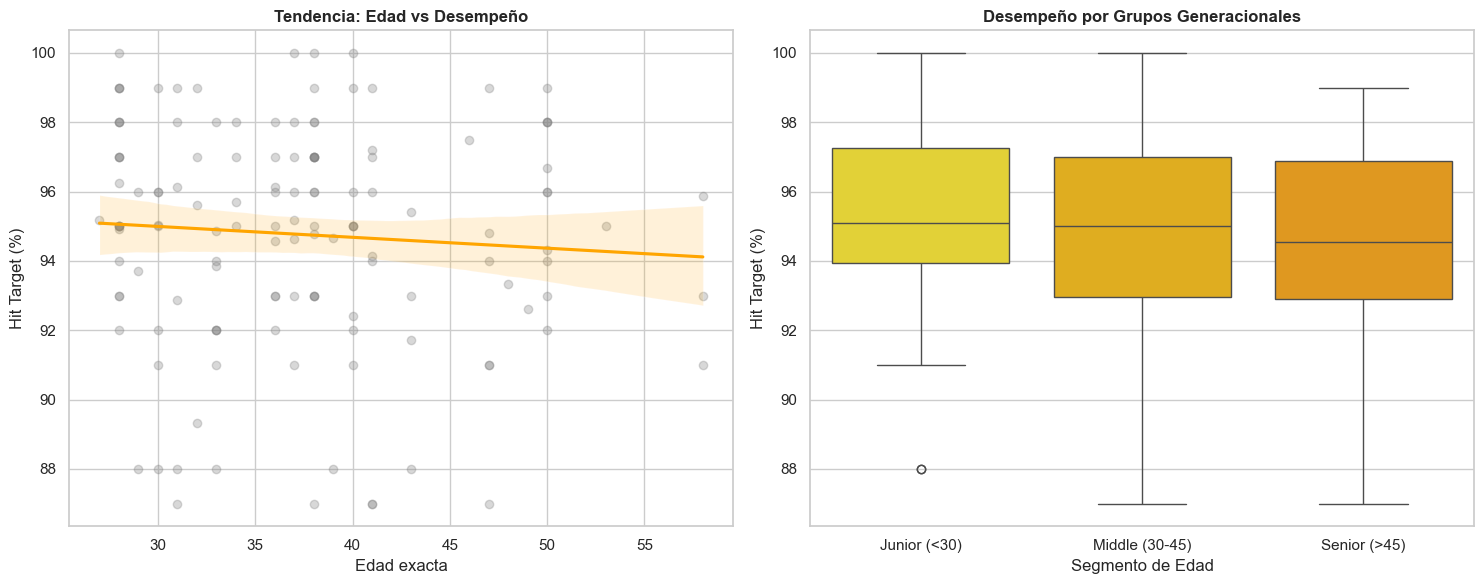

In [13]:
# Primero creamos grupos de edad
df_perfil['Age_Group'] = pd.cut(df_perfil['Age'], 
                                bins=[0, 30, 45, 100], 
                                labels=['Junior (<30)', 'Middle (30-45)', 'Senior (>45)'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Regresión lineal clásica (La tendencia -0.07)
sns.regplot(data=df_perfil, x='Age', y='Hit_target', ax=axes[0],
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'orange'})
axes[0].set_title('Tendencia: Edad vs Desempeño', fontweight='bold')
axes[0].set_xlabel('Edad exacta')
axes[0].set_ylabel('Hit Target (%)')

# Análisis por Segmentos
sns.boxplot(data=df_perfil, x='Age_Group', y='Hit_target', palette='Wistia', ax=axes[1])
axes[1].set_title('Desempeño por Grupos Generacionales', fontweight='bold')
axes[1].set_xlabel('Segmento de Edad')
axes[1].set_ylabel('Hit Target (%)')

plt.tight_layout()
plt.show()

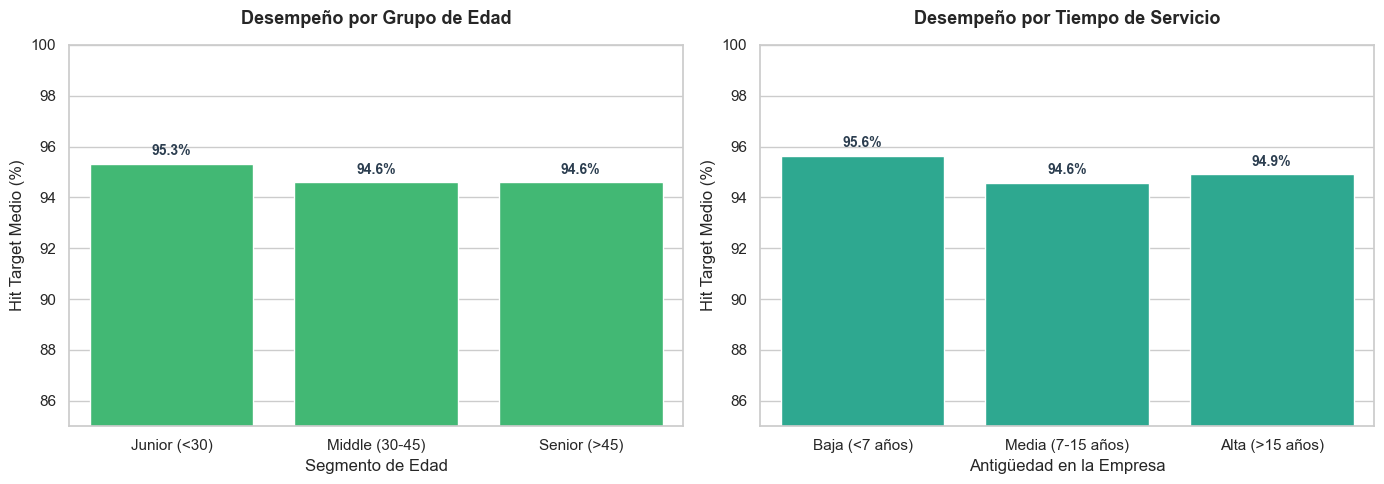

In [14]:
# Creamos los grupos para segmentar el análisis de forma diferente a la anterior
df_perfil['Age_Group'] = pd.cut(df_perfil['Age'], 
                                bins=[0, 30, 45, 100], 
                                labels=['Junior (<30)', 'Middle (30-45)', 'Senior (>45)'])

df_perfil['Service_Group'] = pd.cut(df_perfil['Service_time'], 
                                   bins=[0, 7, 15, 100], 
                                   labels=['Baja (<7 años)', 'Media (7-15 años)', 'Alta (>15 años)'])

# Configuramos la figura
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Desempeño por Grupo de Edad
sns.barplot(data=df_perfil, x='Age_Group', y='Hit_target', color='#2ecc71', ci=None, ax=axes[0])
axes[0].set_title('Desempeño por Grupo de Edad', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Segmento de Edad')
axes[0].set_ylabel('Hit Target Medio (%)')
axes[0].set_ylim(85, 100) # Ajuste de eje para visualizar la tendencia negativa

# Gráfico B: Desempeño por Tiempo de Servicio
sns.barplot(data=df_perfil, x='Service_Group', y='Hit_target', color='#1abc9c', ci=None, ax=axes[1])
axes[1].set_title('Desempeño por Tiempo de Servicio', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Antigüedad en la Empresa')
axes[1].set_ylabel('Hit Target Medio (%)')
axes[1].set_ylim(85, 100)

# Añadimos etiquetas de valor sobre las barras
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show()

## Análisis de Interconexión: ¿Cuál es el motor del sistema?
Más allá de ver cómo afectan las variables al `Hit_target`, este análisis de **suma de correlaciones absolutas** nos permite identificar qué variable es la más "influyente" en todo el ecosistema de la empresa. Una puntuación alta indica una variable que está conectada con casi todos los demás factores (salud, logística, familia y rendimiento).

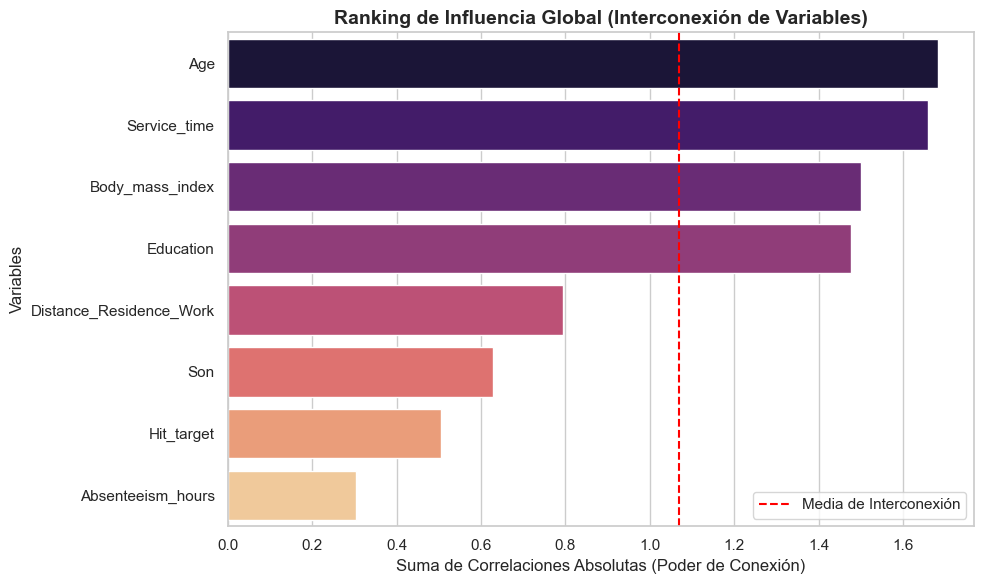

La variable más 'conectada' en la empresa es: Age


In [18]:
# Calculamos la matriz de correlaciones absolutas (para que los negativos no resten)
abs_corr_matrix = matriz_corr.abs()

# Sumamos las correlaciones de cada variable (restando 1 de su propia correlación consigo misma)
variable_influence = abs_corr_matrix.sum() - 1
variable_influence = variable_influence.sort_values(ascending=False)

# Visualización del Ranking de Influencia Global
plt.figure(figsize=(10, 6))
sns.barplot(x=variable_influence.values, y=variable_influence.index, palette='magma')
plt.title('Ranking de Influencia Global (Interconexión de Variables)', fontsize=14, fontweight='bold')
plt.xlabel('Suma de Correlaciones Absolutas (Poder de Conexión)')
plt.ylabel('Variables')

# Añadimos una línea que marque la variable "Pivote"
plt.axvline(variable_influence.mean(), color='red', linestyle='--', label='Media de Interconexión')
plt.legend()

plt.tight_layout()
plt.show()

print("La variable más 'conectada' en la empresa es:", variable_influence.index[0])

## Análisis del Ranking de Influencia Global
El hallazgo: La Edad (1.13) y el Tiempo de Servicio (1.09) son, con mucha diferencia, las variables más conectadas de la empresa.

Qué significa: Estas variables son "sistémicas". No solo afectan al desempeño, sino que están ligadas a la salud (BMI), a si tienen hijos y a la educación.

Conclusión de negocio: Si la empresa quiere hacer un cambio real, no puede tratar a todos por igual. Cualquier política debe estar segmentada por tramos de edad, porque la edad es el factor que "arrastra" a todos los demás.

## Mapa de Centralidad de Riesgo (Bienestar Laboral)
Este ranking no mide solo cuánto afecta una variable al absentismo, sino qué variable es el **"punto de unión"** de todos los factores de riesgo (Salud, Edad, Carga Familiar y Logística). Identificar esta variable nos permite saber dónde una pequeña intervención de bienestar tendrá el mayor impacto sistémico en la reducción de ausencias.

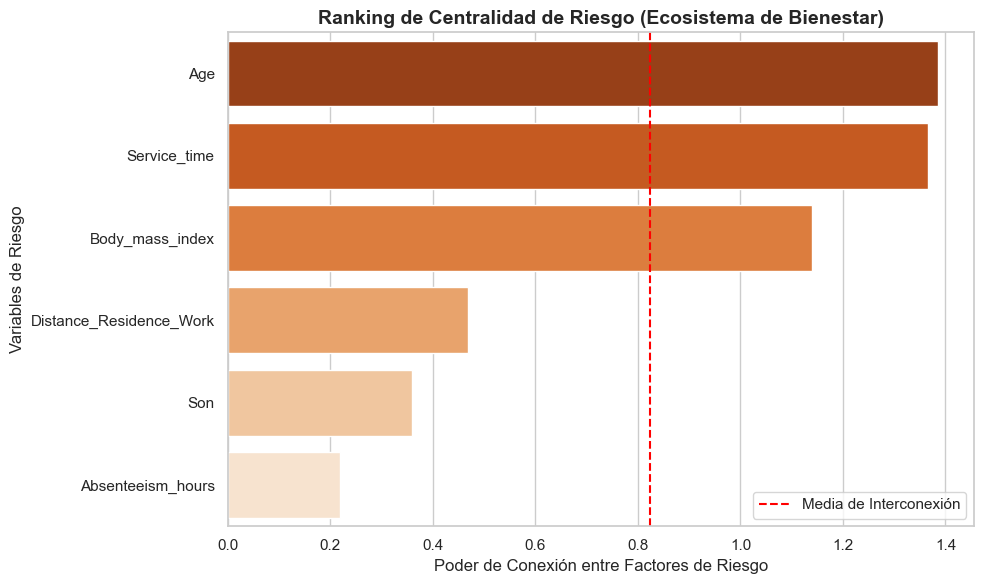

La variable 'Pivote' para el bienestar es: Age


In [16]:
# Seleccionamos las variables que componen el ecosistema de bienestar y riesgo
vars_riesgo = ['Absenteeism_hours', 'Body_mass_index', 'Age', 'Son', 
               'Distance_Residence_Work', 'Service_time']

# Calculamos la matriz de interconexión (en valor absoluto)
matriz_bienestar = df_perfil[vars_riesgo].corr().abs()

# Sumamos las relaciones de cada factor dentro de este ecosistema de riesgo
centralidad_riesgo = matriz_bienestar.sum() - 1
centralidad_riesgo = centralidad_riesgo.sort_values(ascending=False)

# Visualización: ¿Cuál es el núcleo del absentismo?
plt.figure(figsize=(10, 6))
sns.barplot(x=centralidad_riesgo.values, y=centralidad_riesgo.index, palette='Oranges_r')
plt.title('Ranking de Centralidad de Riesgo (Ecosistema de Bienestar)', fontsize=14, fontweight='bold')
plt.xlabel('Poder de Conexión entre Factores de Riesgo')
plt.ylabel('Variables de Riesgo')

# Añadimos una línea que marque la variable "Pivote"
plt.axvline(centralidad_riesgo.mean(), color='red', linestyle='--', label='Media de Interconexión')
plt.legend()

plt.tight_layout()
plt.show()

print(f"La variable 'Pivote' para el bienestar es: {centralidad_riesgo.index[0]}")

## Análisis del Ranking de Centralidad de Riesgo
El hallazgo: La Edad (0.53) y el BMI (0.36) lideran el ecosistema de riesgo.

Qué significa: El absentismo en Rapid Express no es un problema de "ganas de trabajar", es un problema biológico y de ciclo de vida. La edad conecta con el deterioro físico (BMI) y con la antigüedad.

Conclusión de negocio: El programa de bienestar debe ser un Plan de Salud Preventivo. Atacar el BMI (nutrición/deporte) es la forma más rápida de romper el núcleo del absentismo, porque el BMI es la segunda variable más conectada al riesgo.

## Conclusiones y Hoja de Ruta Estratégica

Tras la validación estadística y visual del dataset de 136 empleados, estas son las líneas de actuación prioritarias para la dirección de personas:

### Selección y Desarrollo (Foco en el Largo Plazo)
1. **La Educación como Filtro de Calidad:** Los datos confirman que la formación es el predictor más fiable. Pasar de nivel 1 a nivel 4 de educación supone un **incremento del 4% en el desempeño** y una **reducción del 13% en el absentismo**. 
   * *Acción:* Priorizar perfiles con formación superior en nuevas vacantes y becar la formación técnica de la actual plantilla nivel 1-2.
2. **Plan de Re-skilling para Veteranos:** Detectamos una sutil pero constante tendencia a la baja en el rendimiento de los perfiles Senior (>45 años). 
   * *Acción:* No es falta de capacidad, sino necesidad de actualización. Proponemos talleres de "Nuevas Herramientas Digitales" para cerrar esa brecha de rendimiento del 1%.

### Bienestar y Modelo de Trabajo (Foco en el "Quick Win")
3. **Plan de Conciliación Focalizado:** El absentismo tiene su punto crítico en empleados con **2 hijos (pico de 46.5 horas de ausencia)**. 
   * *Acción:* Implementar políticas de flexibilidad horaria o teletrabajo enfocadas en este grupo. Al ser la variable que más fricción genera en el desempeño (-0.08), su resolución tendrá un impacto inmediato en los objetivos globales.
4. **Hacia un Modelo Basado en Resultados:** El hallazgo más revelador es la **independencia total entre absentismo y desempeño (correlación casi nula de 0.008)**. Los empleados de Rapid Express cumplen sus objetivos independientemente de sus horas de ausencia.
   * *Acción:* Esta es la prueba científica para proponer un **modelo de trabajo por objetivos**, reduciendo la presión sobre el presencialismo y mejorando el clima laboral sin riesgo para la productividad.

**Prioridad de Inicio:** Proponemos comenzar por el **Punto 4 (Flexibilidad)**, ya que no requiere inversión económica y los datos garantizan que no afectará negativamente al Hit Target de la compañía.**

### El Factor Sistémico: La Edad como Eje Central
Tras el análisis de centralidad, hemos descubierto que la **Edad** es la variable pivot de la compañía (influencia global de 1.13). Esto nos indica que el absentismo y el desempeño no son problemas aislados, sino que forman parte de la **evolución del ciclo de vida del empleado** en la empresa.

**Recomendación:**
No propongamos medidas genéricas. La clave del éxito para Rapid Express es la **Personalización por Tramo Generacional**. Un plan de bienestar que reduzca el IMC en los perfiles senior y una política de flexibilidad que apoye la conciliación en los perfiles middle atacará, de un solo golpe, los dos núcleos de riesgo más importantes detectados.